In [2]:
%matplotlib inline

In [3]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#----------
# Inference
#-----------

theta = 0.7
n = 10
print("       M  sample bias  sample variance  true variance")

for M in [10, 100, 1000, 10000, 100000, 1000000, 10000000]:
    sample_theta = np.random.binomial(1, theta, M)
    sample_bias_theta = np.mean(sample_theta) - theta
    sample_variance_theta = np.sum((sample_theta - np.mean(sample_theta)) ** 2) / (M - 1)
    true_var_theta = theta * (1 - theta)
    print('{:8} {:12.2e} {:16.4f} {:16.4f}'.format(M, sample_bias_theta, sample_variance_theta, true_var_theta))

       M  sample bias  sample variance  true variance
      10     1.00e-01           0.1778           0.2100
     100     1.00e-02           0.2080           0.2100
    1000     1.80e-02           0.2027           0.2100
   10000    -7.20e-03           0.2128           0.2100
  100000     5.90e-04           0.2098           0.2100
 1000000    -8.69e-04           0.2103           0.2100
10000000    -1.09e-04           0.2100           0.2100


posterior mean: 0.7
posterior s.d.: 0.13816985594155148


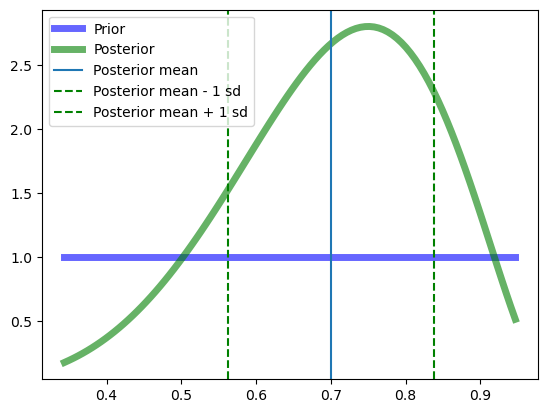

In [57]:
#----------
# Bayesian
#----------

from cProfile import label

from cv2 import line


alpha, beta = 7, 3

posterior_mean, posterior_var, posterior_skew, posterior_kurt = scipy.stats.beta.stats(alpha, beta, moments='mvsk')

xs = np.linspace(scipy.stats.beta.ppf(0.01, alpha, beta), scipy.stats.beta.ppf(0.99, alpha, beta), 100)
plt.plot(xs, [1 for z in xs], 'b-', lw=5, alpha=0.6, label='Prior')
plt.plot(xs, scipy.stats.beta.pdf(xs, alpha, beta), 'g-', lw=5, alpha=0.6, label='Posterior')
plt.axvline(posterior_mean, label='Posterior mean')
posterior_sd = np.sqrt(posterior_var)
plt.axvline(posterior_mean - posterior_sd, label='Posterior mean - 1 sd', color='g', linestyle='dashed')
plt.axvline(posterior_mean + posterior_sd, label='Posterior mean + 1 sd', color='g', linestyle='dashed')
plt.legend(loc='upper left')

print('posterior mean:', posterior_mean)
print('posterior s.d.:', posterior_sd)


posterior mean: 0.6428571428571429
posterior s.d.: 0.12371791482634838


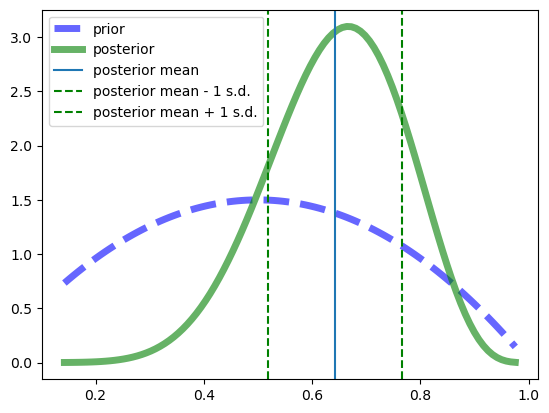

In [58]:
prior_alpha, prior_beta = 2., 2.
posterior_alpha, posterior_beta = prior_alpha + 7, prior_beta + 10 - 7

posterior_mean, posterior_var, posterior_skew, posterior_kurt = scipy.stats.beta.stats(posterior_alpha, posterior_beta, moments='mvsk')

xs = np.linspace(scipy.stats.beta.ppf(0.00001, posterior_alpha, posterior_beta), 
                 scipy.stats.beta.ppf(0.99999, posterior_alpha, posterior_beta), 100)
plt.plot(xs, scipy.stats.beta.pdf(xs, prior_alpha, prior_beta), 'b--', lw=5, alpha=.6, label='prior')
plt.plot(xs, scipy.stats.beta.pdf(xs, posterior_alpha, posterior_beta), 'g-', lw=5, alpha=.6, label='posterior')
plt.axvline(posterior_mean, label='posterior mean')
posterior_sd = np.sqrt(posterior_var)
plt.axvline(posterior_mean - posterior_sd, linestyle='--', color='g', label='posterior mean - 1 s.d.')
plt.axvline(posterior_mean + posterior_sd, linestyle='--', color='g', label='posterior mean + 1 s.d.')
plt.legend(loc='upper left');
print('posterior mean:', posterior_mean)
print('posterior s.d.:', posterior_sd)